## Imports and Setup

In [3]:
# Data handling
import pandas as pd
import numpy as np
# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
# ARIMA implementation
from statsmodels.tsa.arima.model import ARIMA
# Automatic parameter selection
from pmdarima import auto_arima
# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
plt.style.use("seaborn-v0_8")

import json
import os

## Load the Cleaned Dataset

In [4]:
# Load cleaned univariate time series (no split applied here)
data = pd.read_csv(
    "../../data/processed/cleaned_demand_timeseries.csv",
    parse_dates=True,
    index_col=0
)

# Ensure chronological order
data = data.sort_index()
print(f"Data Loaded. Shape: {data.shape}")
data.head()


Data Loaded. Shape: (282144, 2)


,demand,demand_diff
timestamp,,
2023-01-01 00:00:00,18995,NaN
2023-01-01 00:30:00,19730,735.0
2023-01-01 01:00:00,19327,-403.0
2023-01-01 01:30:00,18589,-738.0
2023-01-01 02:00:00,17806,-783.0


## Define Train-Test Split

In [5]:
# Fixed split used across ALL models (ARIMA, LSTM, XGBoost)
SPLIT_RATIO = 0.8

split_idx = int(len(data) * SPLIT_RATIO)
SPLIT_TIMESTAMP = data.index[split_idx]

print(f"Official train-test split timestamp: {SPLIT_TIMESTAMP}")

Official train-test split timestamp: 2023-12-12 20:00:00


## Apply the Split

Training samples: 227013
Testing samples: 60264


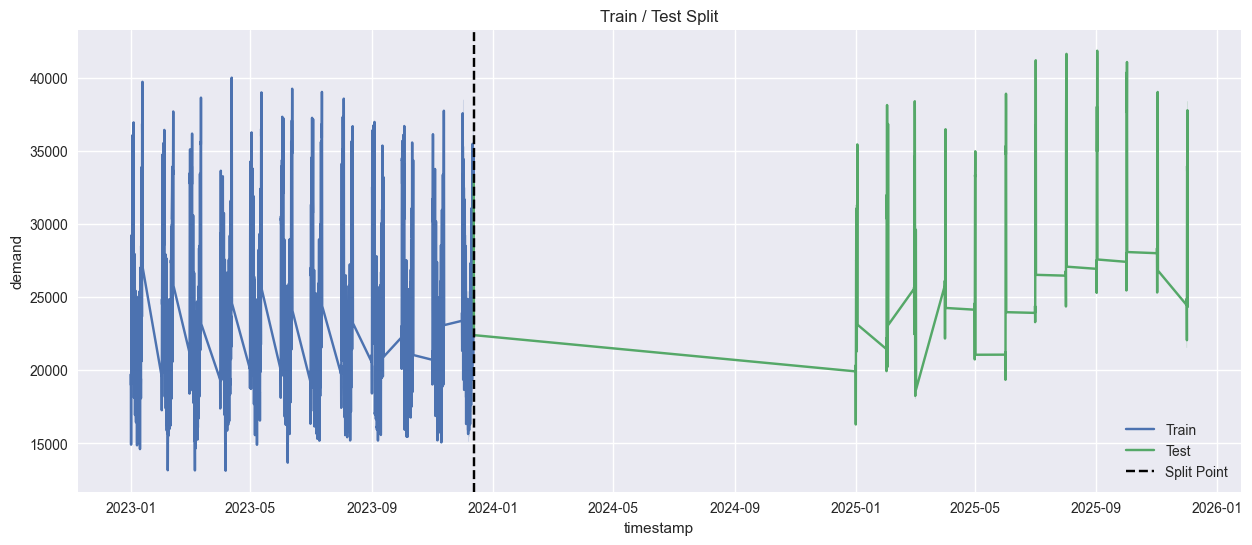

In [6]:
train = data.loc[:SPLIT_TIMESTAMP]
test = data.loc[SPLIT_TIMESTAMP:]

print(f"Training samples: {len(train)}")
print(f"Testing samples: {len(test)}")

# Visualize the split using Seaborn
plt.figure(figsize=(15, 6))
sns.lineplot(data=train, x=train.index, y='demand', label='Train')
sns.lineplot(data=test, x=test.index, y='demand', label='Test')
plt.axvline(SPLIT_TIMESTAMP, color='black', linestyle='--', label='Split Point')
plt.title('Train / Test Split')
plt.legend()
plt.show()

## Parameter Tuning (Auto-ARIMA)

In [7]:
## Parameter Tuning (Auto-ARIMA) on Subset
# We use the last 10,000 rows (approx. 7 months) to find parameters quickly.
# This avoids waiting hours for the search to complete on 200k+ rows.
subset_size = 10000
search_subset = train['demand'].iloc[-subset_size:]

print(f"Searching for optimal (p,d,q) using the last {subset_size} samples...")

auto_model = auto_arima(
    search_subset,
    seasonal=False,  
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=True
)

print(f"Best parameters found: {auto_model.order}")
print(auto_model.summary())

Searching for optimal (p,d,q) using the last 10000 samples...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=199905.046, Time=3.05 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=206977.338, Time=0.31 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=203981.851, Time=0.67 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=199842.609, Time=4.70 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=206975.338, Time=0.22 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=199829.966, Time=7.47 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=200072.417, Time=6.38 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=199884.826, Time=12.93 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=199829.283, Time=6.73 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=199886.317, Time=7.64 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=199879.743, Time=7.49 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=199827.340, Time=3.76 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=199840.667, Time=2.67 sec
 ARIMA(1,1

## Train the final ARIMA Model

In [8]:
## Train the final ARIMA Model on FULL Data
# Extract optimal order from the subset search
order = auto_model.order
print(f"Fitting final ARIMA model with order {order} on the FULL training set...")

# Train on the FULL training set (not just the subset)
# We use train['demand'] to ensure we pass a 1D Series, not a DataFrame
arima_model = ARIMA(train['demand'], order=order)

# method='innovations_mle' is faster for large datasets, but default is fine too
arima_results = arima_model.fit()

print(arima_results.summary())

Fitting final ARIMA model with order (0, 1, 2) on the FULL training set...


c:\Users\ariel\OneDrive\Documents\GitHub\energy-consumption-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ariel\OneDrive\Documents\GitHub\energy-consumption-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ariel\OneDrive\Documents\GitHub\energy-consumption-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                 demand   No. Observations:               227013
Model:                 ARIMA(0, 1, 2)   Log Likelihood            -2268709.785
Date:                Tue, 10 Feb 2026   AIC                        4537425.570
Time:                        11:50:07   BIC                        4537456.569
Sample:                             0   HQIC                       4537434.644
                             - 227013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9824      0.002   -519.902      0.000      -0.986      -0.979
ma.L2          0.0083      0.002      4.375      0.000       0.005       0.012
sigma2      2.806e+07   1.02e-12   2.74e+19      0.0

## Generate Forecasts

In [9]:
## Generate Forecasts (FIXED)
# Forecast for the length of the test period
# .values ensures we take just the raw numbers, preventing index mismatch errors
forecast_values = arima_results.forecast(steps=len(test)).values

# Create a clean Series with the correct test index
forecast = pd.Series(forecast_values, index=test.index)

print("Forecast generated successfully.")
print(f"First 5 predictions:\n{forecast.head()}")

c:\Users\ariel\OneDrive\Documents\GitHub\energy-consumption-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\ariel\OneDrive\Documents\GitHub\energy-consumption-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Forecast generated successfully.
First 5 predictions:
timestamp
2023-12-12 20:00:00    32303.064012
2023-12-12 20:00:00    32349.727699
2023-12-12 20:00:00    32349.727699
2023-12-12 20:00:00    32349.727699
2023-12-12 20:00:00    32349.727699
dtype: float64


## Visualise Forecast vs Actual

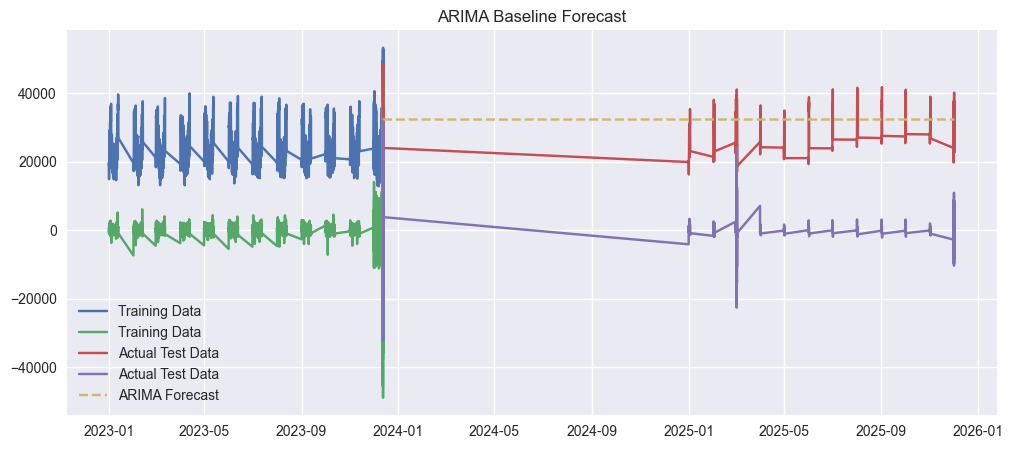

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(train, label="Training Data")
plt.plot(test, label="Actual Test Data")
plt.plot(forecast, label="ARIMA Forecast", linestyle="--")
plt.title("ARIMA Baseline Forecast")
plt.legend()
plt.show()

## Model Evaluation

In [11]:
## Model Evaluation
# Align actuals and forecast in a DataFrame to be safe
eval_df = pd.DataFrame({
    'actual': test['demand'],
    'forecast': forecast
})

# Drop NaNs (should be 0 now, but good practice)
eval_df = eval_df.dropna()

# Calculate metrics
rmse = np.sqrt(mean_squared_error(eval_df['actual'], eval_df['forecast']))
mae = mean_absolute_error(eval_df['actual'], eval_df['forecast'])

print(f"--- Scores to Beat (Save These!) ---")
print(f"ARIMA RMSE: {rmse:.3f}")
print(f"ARIMA MAE:  {mae:.3f}")

--- Scores to Beat (Save These!) ---
ARIMA RMSE: 7330.804
ARIMA MAE:  6087.555


In [12]:
# Create results directory if it doesn't exist
os.makedirs('../results', exist_ok=True)

# Save metrics to a JSON file
arima_results = {
    'model_name': 'ARIMA (Baseline)',
    'rmse': float(rmse),
    'mae': float(mae)
}

with open('../results/arima_metrics.json', 'w') as f:
    json.dump(arima_results, f)

## Store for Comparison

In [13]:
baseline_results = {
    "Model": "ARIMA",
    "RMSE": rmse,
    "MAE": mae
}

baseline_results

{'Model': 'ARIMA',
 'RMSE': np.float64(7330.803803906474),
 'MAE': 6087.555204074608}